# no5 · Blooper (non-speech) detection

Input: a podcast/newscast video. Output: one clip per span where the speaker(s)
are **not** talking (silence, pauses, music, cutaways, dropped mics).

Pipeline: `extract_audio` → Silero VAD `speech_spans` → invert to
`nonspeech_spans` → MediaPipe `lip_motion_score` (confirm lips static) →
`cut_clips`.

**Prereqs:** `brew install ffmpeg`, then `pip install -r requirements.txt`.
Drop a short clip in `input/`.

In [1]:
import importlib
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

import blooper
importlib.reload(blooper)  # re-pick edits to blooper.py without restarting

# Point at the first video in input/
vids = sorted(p for p in Path('input').glob('*') if p.suffix.lower() in {'.mp4', '.mov', '.mkv', '.m4v'})
assert vids, 'Put a podcast/newscast video in input/'
VIDEO = str(vids[0])
DUR = blooper.video_duration(VIDEO)
print(f'{VIDEO}  ({DUR:.1f}s)')

input/Movie on 25-06-26 at 17.14.mov  (131.6s)


## 1–2. Extract audio + run Silero VAD

In [2]:
%pip install torchaudio opencv-python mediapipe soundfile matplotlib


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
wav = blooper.extract_audio(VIDEO)
speech = blooper.speech_spans(wav)
Path(wav).unlink(missing_ok=True)
print(f'{len(speech)} speech segment(s)')
speech[:5]

Using cache found in /Users/angie/.cache/torch/hub/snakers4_silero-vad_master


46 speech segment(s)


[(1.122, 2.014),
 (2.722, 3.742),
 (4.002, 8.766),
 (11.202, 12.19),
 (12.866, 13.598)]

## 3. Invert → candidate non-speech spans

Tune `min_dur` / `merge_gap` here for podcast vs newscast footage.

21 candidate blooper span(s)


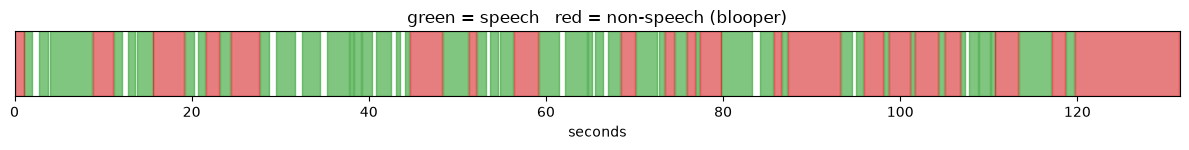

In [4]:
MIN_DUR, PAD, MERGE_GAP = 0.8, 0.1, 0.3
gaps = blooper.nonspeech_spans(speech, DUR, min_dur=MIN_DUR, pad=PAD, merge_gap=MERGE_GAP)
print(f'{len(gaps)} candidate blooper span(s)')

fig, ax = plt.subplots(figsize=(12, 1.6))
for s, e in speech:
    ax.axvspan(s, e, color='tab:green', alpha=0.6)
for s, e in gaps:
    ax.axvspan(s, e, color='tab:red', alpha=0.6)
ax.set_xlim(0, DUR); ax.set_yticks([]); ax.set_xlabel('seconds')
ax.set_title('green = speech   red = non-speech (blooper)')
plt.tight_layout(); plt.show()

## 4. Visual lip-motion check

For each candidate span, MediaPipe FaceMesh measures mouth-aperture variance.
Low → `silent`; high → `lips_moving` (speaker mouthing while audio silent);
no face → `no_face` (audio-only verdict).

In [5]:
LIP_THRESHOLD = 1e-3
rows = []
for s, e in gaps:
    lm = blooper.lip_motion_score(VIDEO, s, e)
    rows.append(blooper.Blooper(s, e, round(e - s, 3), lm, blooper._label(lm, LIP_THRESHOLD)))

df = pd.DataFrame([b.__dict__ for b in rows])
df

,start,end,duration,lip_motion,label
0,0.100,1.022,0.922,NaN,no_face
1,8.866,11.102,2.236,0.022279,lips_moving
2,15.682,19.166,3.484,0.025951,lips_moving
3,21.602,23.102,1.500,0.014836,lips_moving
4,24.482,27.582,3.100,0.012867,lips_moving
5,44.642,48.286,3.644,0.133179,lips_moving
6,51.298,52.158,0.860,NaN,no_face
7,56.354,59.070,2.716,0.075845,lips_moving
8,68.514,70.046,1.532,0.044295,lips_moving
9,73.474,74.430,0.956,NaN,no_face


## 5. Cut individual clips + write index

In [6]:
index = blooper.cut_clips(
    VIDEO, rows, outdir='out',
    params={'min_dur': MIN_DUR, 'pad': PAD, 'merge_gap': MERGE_GAP, 'lip_threshold': LIP_THRESHOLD},
)
print(f"{index['count']} clip(s) written to out/clips/")
for f in sorted(Path('out/clips').glob('*.mp4')):
    print(' ', f.name)

21 clip(s) written to out/clips/
  blooper_000_0.1-1.0.mp4
  blooper_001_8.9-11.1.mp4
  blooper_002_15.7-19.2.mp4
  blooper_003_21.6-23.1.mp4
  blooper_004_24.5-27.6.mp4
  blooper_005_44.6-48.3.mp4
  blooper_006_51.3-52.2.mp4
  blooper_007_56.4-59.1.mp4
  blooper_008_68.5-70.0.mp4
  blooper_009_73.5-74.4.mp4
  blooper_010_75.9-76.8.mp4
  blooper_011_77.3-79.7.mp4
  blooper_012_85.7-86.6.mp4
  blooper_013_87.3-93.2.mp4
  blooper_014_95.9-98.0.mp4
  blooper_015_98.7-101.1.mp4
  blooper_016_101.7-104.2.mp4
  blooper_017_105.1-106.8.mp4
  blooper_018_110.8-113.3.mp4
  blooper_019_117.1-118.7.mp4
  blooper_020_119.7-131.5.mp4


## One-shot equivalent

Everything above is also `blooper.detect(VIDEO)` + `blooper.cut_clips(...)`, or
from the shell: `python blooper.py input/yourvideo.mp4`.